In [31]:
import pandas as pd
#램 가격 데이터(Mbyte 단위)
df = pd.read_csv('c:/data/ram/ram_price.csv')
df.head()

,date,price
0,1957.0,411041792.0
1,1959.0,67947725.0
2,1960.0,5242880.0
3,1965.0,2642412.0
4,1970.0,734003.0


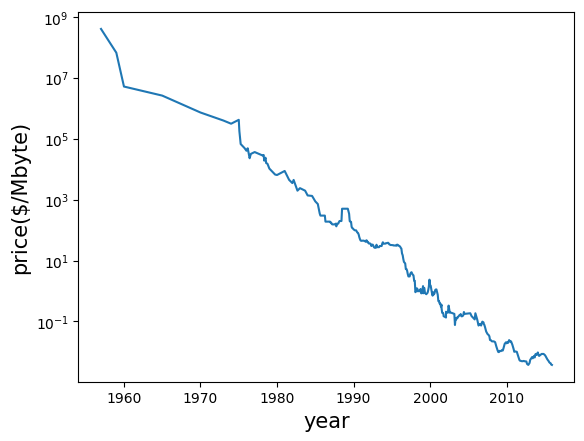

In [32]:
import matplotlib.pyplot as plt
#y축 로그 스케일
plt.semilogy(df['date'],df['price'])
plt.xlabel('year', size=15)
plt.ylabel('price($/Mbyte)', size=15)
plt.show()
#시간이 지날수록 램 가격은 점차 하락하고 있음

In [33]:
import numpy as np
#학습용과 검증용을 2000년 기준으로 구분
X_train0 = df[df['date']<2000]
X_test = df[df['date']>=2000]
X_train = np.array(X_train0['date'])[:,None]
#y값을 로그 스케일로 변환
y_train = np.log(X_train0['price'])
y_test= np.log(X_test['price'])

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

tree = DecisionTreeRegressor().fit(X_train, y_train)  #의사결정나무
lr = LinearRegression().fit(X_train, y_train)  #선형회귀모델
# svr = SVR(kernel='linear').fit(X_train.reshape(-1,1), y_train)
svr = SVR(kernel='rbf').fit(X_train, y_train)

In [35]:
#전체 기간의 자료
#지수함수 np.exp()로 로그값 되돌리기
x_all = np.array(df['date']).reshape(-1,1)
pred_tree = tree.predict(x_all)
price_tree = np.exp(pred_tree)
pred_lr = lr.predict(x_all)
price_lr = np.exp(pred_lr)
pred_svr = svr.predict(x_all)
price_svr = np.exp(pred_svr)

In [36]:
X_test['price'].values.reshape(-1,1)

array([[1.56  ],
       [1.48  ],
       [1.08  ],
       [0.84  ],
       [0.7   ],
       [0.9   ],
       [0.77  ],
       [0.84  ],
       [1.07  ],
       [1.12  ],
       [1.12  ],
       [0.9   ],
       [0.75  ],
       [0.464 ],
       [0.464 ],
       [0.383 ],
       [0.387 ],
       [0.305 ],
       [0.352 ],
       [0.27  ],
       [0.191 ],
       [0.191 ],
       [0.169 ],
       [0.148 ],
       [0.134 ],
       [0.207 ],
       [0.193 ],
       [0.193 ],
       [0.33  ],
       [0.193 ],
       [0.193 ],
       [0.176 ],
       [0.076 ],
       [0.126 ],
       [0.115 ],
       [0.133 ],
       [0.129 ],
       [0.143 ],
       [0.148 ],
       [0.16  ],
       [0.166 ],
       [0.174 ],
       [0.148 ],
       [0.146 ],
       [0.156 ],
       [0.203 ],
       [0.176 ],
       [0.185 ],
       [0.149 ],
       [0.116 ],
       [0.185 ],
       [0.112 ],
       [0.073 ],
       [0.082 ],
       [0.073 ],
       [0.088 ],
       [0.098 ],
       [0.092 ],
       [0.082 

In [37]:
from sklearn.metrics import mean_squared_error
#rms 평균제곱근오차
y_pred = tree.predict(X_test['price'].values.reshape(-1,1)) #회귀트리
rms = np.sqrt(mean_squared_error(y_test, y_pred))
print(rms)
y_pred = lr.predict(X_test['price'].values.reshape(-1,1))  #선형
rms = np.sqrt(mean_squared_error(y_test, y_pred))
print(rms)
y_pred = svr.predict(X_test['price'].values.reshape(-1,1))
rms = np.sqrt(mean_squared_error(y_test, y_pred))
print(rms)

23.038370257895192
861.08402279523
10.42933757466685


Text(0, 0.5, 'price($/Mbyte)')

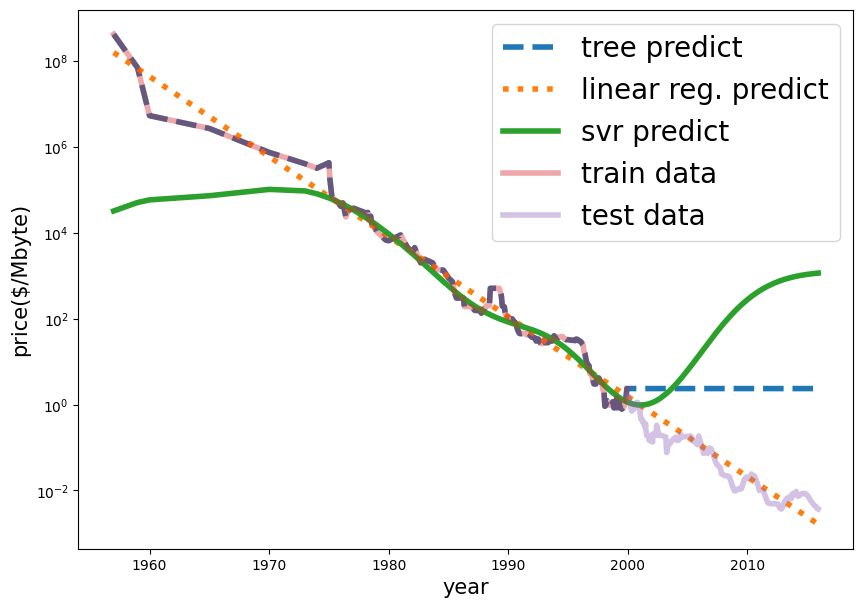

In [38]:
#실제값과 결정트리모형의 예측값, 선형회귀모형의 예측값 비교
plt.figure(figsize=(10,7))
plt.semilogy(df['date'], price_tree, label='tree predict', lw=4, ls='--')
plt.semilogy(df['date'], price_lr, label='linear reg. predict', lw=4, ls=':')
plt.semilogy(df['date'], price_svr, label='svr predict', lw=4, ls='-')
plt.semilogy(X_train0['date'], X_train0['price'], lw=4, label='train data', alpha=0.4)
plt.semilogy(X_test['date'], X_test['price'], lw=4, label='test data', alpha=0.4)
plt.legend(loc=1, fontsize=20)
plt.xlabel('year', size=15)
plt.ylabel('price($/Mbyte)', size=15)